# A Story Map about Herons

* **Authors**: Gongmingyue Tang (IOER) 

```{warning}
This chapter is a work in progress.
```

## What is a story map

A story map is a way of telling a story when the data comes with a map. The reader scrolls, the text arrives in chapters, and the map flies to a new place for each one. The scrollytelling part offers map navigation that guides your audience through the narrative.

Story maps have been a popular format for a few years now, and there are both commercial and open source tools for making them, such as ESRI StoryMaps or JupyterGIS.

Further reading, if you want the theory behind the format: [Caquard and Cartwright (2014)](https://doi.org/10.1179/0008704114Z.000000000130) call the whole field *narrative cartography*, and [Roth (2021)](https://doi.org/10.1080/00087041.2019.1633103) sorts map stories into genres by whichever device carries the reader through them, which is where scrollytelling gets its name.

## About this chapter

Here I would like to show how to process the data and write the config file in Python, using a story map template to put the story together.

The template behind it is written with HTML, CSS and JavaScript, with [MapLibre GL](https://maplibre.org/maplibre-gl-js/docs/examples/fly-to-a-location-based-on-scroll-position/) drawing the map and [Scrollama](https://github.com/russellsamora/scrollama#scrollamajs) watching the scroll position. If you know those languages, the template sits in `py/modules/storymap_template/` and you could edit it directly for more customised changes. If you do not, you never have to open them, because everything a story needs sits in one `_config.json` file: a cover, then a list of chapters, and each chapter is a title, a description, an alignment for the text box (lefty, righty, centered or fully) and a camera position of center, zoom, bearing and pitch.

The way I show here is with a Jupyter notebook. Start from exploring the data (following the starter kit tutorial), then write the chapters, then save them into the story map config. The final product is generated inside the storymap folder, with index.html, the script, the styles, the assets and `_config.json` all in one place, so you can open it locally or upload the whole folder to a web host.

Helper functions in storybuilder.py can be used to:

- `write_chapter`: assemble one chapter. Give it a title, the html of the card, where the camera should sit and which side the text box takes, and it returns the dict the config expects, with the camera fields filled in. It also refuses an alignment the stylesheet does not know, because a misspelled one costs the chapter its layout on the page without raising anything.
- `geojson_layer`: configure how a GeoJSON file should be drawn, as colour, size, opacity and outline. Writing it apart from the chapter keeps the styling next to the palette it belongs to, and lets two chapters draw the same file, sharing one copy of the data instead of fetching it twice.
- `preview_map`: show an ipyleaflet map with a live readout of center and zoom underneath, already converted to what the template wants, longitude first and one zoom level lower than Leaflet, so you can find a camera position by dragging the map instead of guessing numbers.
- `chapter_preview`: draw the chapter's text box over a live map, so you can drag the map around until the framing looks right. It might look a bit different from the final page, since a different map rendering library is used here, but it gives a quick view of the map and the chapter box position. The line underneath gives you the center and zoom already converted for the template, ready to paste into the chapter.
- `save_story`: validate the chapter writing and save the configuration. It copies the template and the styles into the site folder, brings along everything sitting in your `assets` folder, then runs the same checks over the finished config. If anything is wrong it reports every problem at once, and leaves your previous build untouched.


### The Inspiration and Storyline Sketch

```{dropdown} My personal motivation (inspiration) for the story
I was so obsessed with night heron memes on social media, and then found out these birds are actually kind of famous for moving into cities. Quite a few species in the heron family have become proper city birds. They nest in park trees, fish in canals, and hang around people without much fuss. Urban ecologists call them *urban adapters*. They don't just put up with a city, they make a living in it.

But adapting doesn't mean needing nothing. Herons still want tall trees to nest in and water to hunt in, and a city either keeps those two close together or it doesn't.

So I wanted to make a story map about them. And I have the data from the starter kit, so why not find out what story the data could tell us?
```

![Sketch of the story line](../resources/storysketch.png "Sketch of the story line")

### Setup

Import the libraries needed for this chapter


In [1]:
import json
import math
import os
import sys
import time
from collections import Counter
from pathlib import Path
from urllib.parse import urlencode

import matplotlib.pyplot as plt
import numpy as np
import rasterio
import requests
from dotenv import load_dotenv
from ipyleaflet import GeoJSON, Map, TileLayer, basemaps, projections
from owslib.wcs import WebCoverageService
from pyproj import Transformer

# storybuilder.py lives in py/modules, next to tools.py, and does the story map
# side: writing chapters, previewing them on a map, and saving the site. It is
# imported the same way the other chapters import modules/tools.py.
module_path = str(Path.cwd().parents[0] / "py")
if module_path not in sys.path:
    sys.path.append(module_path)
from modules.storybuilder import (chapter_preview, geojson_layer, preview_map,
                                  save_story, write_chapter)

# Everything the story map needs beyond the template - the figures saved below,
# the GeoJSON layers, the cover image - lives here, and save_story copies the
# whole folder into the site at the end.
Path("assets").mkdir(exist_ok=True)


### Starting data exploration
I started with the big picture: where herons live around the world. Herons are the family *Ardeidae*, so I search GBIF for the taxon key under that name (see the [detailed tutorial](#accessing-biodiversity-data)). Caching the result keeps the notebook from asking the API the same question twice.

In [2]:
CACHE_PATH = Path.cwd() / "raw" / "gbif_Taxon_Ardeidaes.json"
cache = json.loads(CACHE_PATH.read_text(encoding="utf-8")) if CACHE_PATH.exists() else {}

search_name = "Ardeidae"

if search_name in cache:
    match = cache[search_name]
    print(f"{search_name}: read from cache, GBIF not called")
else:
    response = requests.get(
        "https://api.gbif.org/v2/species/match",
        params={"scientificName": search_name},
        timeout=30,
    )
    response.raise_for_status()
    match = response.json()

    if match.get("diagnostics", {}).get("matchType") == "NONE":
        raise ValueError(f"GBIF found no taxon matching {search_name!r}")

    cache[search_name] = match
    CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    CACHE_PATH.write_text(json.dumps(cache, indent=2), encoding="utf-8")
    print(f"{search_name}: fetched from GBIF, cached in {CACHE_PATH.name}")


Ardeidae: fetched from GBIF, cached in gbif_Taxon_Ardeidaes.json


Check the fetched result:

In [3]:
match

{'usage': {'key': '3685',
  'name': 'Ardeidae',
  'canonicalName': 'Ardeidae',
  'rank': 'FAMILY',
  'status': 'ACCEPTED',
  'type': 'SCIENTIFIC',
  'formattedName': '<i>Ardeidae</i>'},
 'classification': [{'key': '1', 'name': 'Animalia', 'rank': 'KINGDOM'},
  {'key': '44', 'name': 'Chordata', 'rank': 'PHYLUM'},
  {'key': '212', 'name': 'Aves', 'rank': 'CLASS'},
  {'key': '7190953', 'name': 'Pelecaniformes', 'rank': 'ORDER'},
  {'key': '3685', 'name': 'Ardeidae', 'rank': 'FAMILY'}],
 'diagnostics': {'matchType': 'EXACT',
  'confidence': 94,
  'timeTaken': 1,
  'timings': {'nameNRank': 0,
   'sciNameMatch': 1,
   'nameParse': 0,
   'luceneMatch': 1}},
 'synonym': False,
 'left': 1085328,
 'right': 1085639}

So the taxon key is

In [4]:
Taxon_Ardeidae = match["usage"]["key"]
print(f"{search_name} -> {Taxon_Ardeidae}  ")

Ardeidae -> 3685  


With the key in hand, I can query for the occurrence map with the help of [GBIF Maps API](https://techdocs.gbif.org/en/openapi/v2/maps)

[ipyleaflet](https://ipyleaflet.readthedocs.io) gives us an interactive map widget inside the Jupyter notebook. That helps here, because every story chapter needs a center point for its map view, and it is much easier to find a good one by moving a map than by guessing coordinates.

In this publication material the interactive widget is switched off, so the preview outputs below are PNG screenshots rather than live map views. That keeps the chapter light and lets it render everywhere.

In [5]:
# BaseMap for preview, in storymap a different basemap service will be used.
# Each chapter gets its own map below, all built on this one basemap, so a
# chapter's view stays where you left it while you frame the next one.
BASEMAP = basemaps.OpenStreetMap.Mapnik

m_world = Map(
    basemap=BASEMAP,
    center=(20.00000, 10.00000),
    zoom=2,
    crs=projections.EPSG3857
)


In [6]:
GBIF_TILES = (
    "https://api.gbif.org/v2/map/occurrence/density/{z}/{x}/{y}@2x.png"
    "?style=green-noborder.poly"
    "&bin=hex"
    "&hexPerTile=70"
    "&hasCoordinate=true"
    "&hasGeospatialIssue=false"
    "&occurrenceStatus=PRESENT"
    "&srs=EPSG:3857"
    f"&taxonKey={Taxon_Ardeidae}"
)

In [7]:
gbif_layer = TileLayer(
    url = GBIF_TILES,
    name = "GBIF occurrences (Ardeidae)",
    attribution = 'Occurrences: <a href="https://www.gbif.org">GBIF</a>',
    max_zoom = 16,
    opacity = 0.85,
)

In [8]:
m_world.add(gbif_layer)

preview_map(m_world)


![GBIF occurrence density for Ardeidae, worldwide](../resources/heron_map_world.png "GBIF occurrence density for Ardeidae, worldwide")

The map is dense over Europe, East Asia and the eastern United States.

Notes: Some of that is where herons live. A lot of it is where birdwatchers live. GBIF shows the places people go to and report from, so countries with a strong citizen science habit may look more packed, while tropical regions that probably hold more heron species look thin, simply because fewer people are out there recording.

These are sightings, not populations, so you cannot put the raw counts from two regions side by side and call one of them richer in herons.

#### Story Chapter 1: a chapter about global distribution

Let's try to write a chapter about it. The map shows that herons are widely distributed all over the world.

In [9]:
lat, lon = m_world.center   # ipyleaflet gives (lat, lon), MapLibre wants [lon, lat]
zoom = round(m_world.zoom - 1, 2)         # MapLibre counts zoom on 512px tiles and Leaflet on 256px, so it sits one lower

chapter_text = """Herons are recorded on every continent except Antarctica, wherever there is water to hunt in.
The empty places on this map are not empty. They are the places nobody watched. Even there, the scattered records follow a river or a coast.
"""

chapter_title = "Globally distributed"


In [10]:
chapter1 = write_chapter(title = chapter_title,
                        text = chapter_text,
                        align = "lefty",
                        wmslayer = GBIF_TILES,
                        center = [lon, lat],
                        zoom = zoom)

`chapter_preview` draws the text card over a map. The purpose is to preview the
layout and decide the map position more easily. It does not read the
chapter's `data` or `wmslayer` keys, so a preview is only honest if the map
handed to it carries the layers that chapter actually uses. 

In [11]:
chapter_preview(chapter1, m_world)


![Chapter 1 preview: the global distribution card](../resources/heron_chapter1_global.png "Chapter 1 preview: the global distribution card")

Drag the map and run the cell above again, or paste the new numbers straight into the chapter. Either way the chapter keeps the camera position you leave it at.

### Zooming to Germany

Let's continue with two questions:
**Which herons live in Germany?** (Count the records.)
**Which ones are the city birds?** (Compare how much of each species' records land in built-up places.)

#### Which herons are common in Germany?

I run one filtered query to do the counting. The GBIF Search API can group records by species and hand back the totals, and with `limit=0` nothing gets downloaded. The seven species with the most records come out as taxon keys, and each key is looked up afterwards to get its scientific and common name.

GBIF returns every English name any dataset has ever attached to a bird, in no particular order. I take the one that shows up most often, which gives me the name people actually use.

The filters are written once and reused by every step below, so the species list and the statistics always describe the same records. Breeding season only, April to July, and 2015 onwards. That leaves out birds that were only passing through, which would otherwise make the rare species look more common than they are.

The files are cached as well.

In [12]:
SEARCH   = "https://api.gbif.org/v1/occurrence/search"
SPECIES  = "https://api.gbif.org/v1/species"
TOP_N    = 7

FILTERS = dict(country="DE", hasCoordinate="true", hasGeospatialIssue="false",
               month="4,7", year="2015,2026")

# Cache file names carry the filters, so a changed filter gives a new file
# instead of a stale answer to a different question.
TAG = (f"top{TOP_N}_{FILTERS['year'].replace(',', '-')}"
       f"_m{FILTERS['month'].replace(',', '-')}")
RAW = Path("raw")
RAW.mkdir(exist_ok=True)

species_cache = RAW / f"species_{TAG}.json"

if species_cache.exists():
    species = json.loads(species_cache.read_text(encoding="utf-8"))
    print(f"{species_cache.name}: read from cache, GBIF not called")
else:
    # rank the family's species by how many records inside Germany each one has
    facets = requests.get(SEARCH, params={**FILTERS, "taxonKey": Taxon_Ardeidae,
                                          "facet": "speciesKey", "facetLimit": 30,
                                          "limit": 0}, timeout=90).json()
    species = []
    for entry in facets["facets"][0]["counts"][:TOP_N]:
        key = int(entry["name"])
        scientific = requests.get(f"{SPECIES}/{key}", timeout=30).json()["canonicalName"]
        vernaculars = requests.get(f"{SPECIES}/{key}/vernacularNames",
                                   params={"limit": 200}, timeout=30).json()["results"]
        english = [v["vernacularName"] for v in vernaculars if v.get("language") == "eng"]
        common = Counter(english).most_common(1)[0][0]
        species.append({"key": key, "scientific": scientific,
                        "name": common, "records": entry["count"]})

    species_cache.write_text(json.dumps(species, indent=2), encoding="utf-8")
    print(f"{species_cache.name}: fetched from GBIF, cached")

print(f"\n{'key':<10}{'scientific':<24}{'common name':<28}{'records':>9}")
for s in species:
    print(f"{s['key']:<10}{s['scientific']:<24}{s['name']:<28}{s['records']:>9,}")

species_top7_2015-2026_m4-7.json: read from cache, GBIF not called

key       scientific              common name                   records
9797180   Ardea cinerea           Grey Heron                    113,264
9752617   Ardea alba              Great Egret                    19,464
2480934   Ardea purpurea          Purple Heron                    3,131
2480910   Botaurus stellaris      Eurasian Bittern                1,777
2480863   Nycticorax nycticorax   Black-crowned Night Heron       1,651
2480876   Egretta garzetta        Little Egret                    1,505
2480850   Ixobrychus minutus      Little Bittern                    607


Now get all the observation points. This also prepares the next step, where I evaluate how urban each species is.

In [13]:
POINTS = RAW / "points"
POINTS.mkdir(parents=True, exist_ok=True)

for s in species:
    cache = POINTS / f"{s['key']}_{TAG}.npy"

    if cache.exists():
        s["points"] = np.load(cache)
        note = "cached"
    else:
        found = []
        for year in range(2015, 2027):
            offset = 0
            while True:
                # A failed request answers with a json list, not the usual
                # dict, so page["results"] below would raise a TypeError that
                # says nothing about what went wrong. GBIF's 503s are usually
                # brief, and one of them should not throw away a download of
                # several hundred pages, so wait and ask again.
                for attempt in range(5):
                    response = requests.get(SEARCH, params={**FILTERS, "speciesKey": s["key"],
                                                            "year": str(year), "limit": 300,
                                                            "offset": offset}, timeout=120)
                    if response.ok:
                        break
                    print(f"  {s['name']} {year}: HTTP {response.status_code}, retrying")
                    time.sleep(2 ** attempt)

                response.raise_for_status()
                page = response.json()
                for r in page["results"]:
                    if r.get("decimalLongitude") is not None:
                        found.append((r["decimalLongitude"], r["decimalLatitude"]))
                offset += 300
                if page["endOfRecords"] or offset >= min(page["count"], 100000):
                    break
        s["points"] = np.array(found, dtype="float64")
        np.save(cache, s["points"])
        note = "downloaded"

    print(f"{s['name']:<28}{len(s['points']):>8,} points   {note}")

Grey Heron                   113,256 points   cached
Great Egret                   19,464 points   cached
Purple Heron                   3,130 points   cached
Eurasian Bittern               1,777 points   cached
Black-crowned Night Heron      1,651 points   cached
Little Egret                   1,503 points   cached
Little Bittern                   607 points   cached


#### How built-up is the place each bird was seen?

The IOER Monitor provides open data on urban density. A detailed tutorial for retrieving the data can be found in the [training material](https://training.fdz.ioer.info/notebooks/203_data_retrieval_monitor.html). As in the tutorial, I took the indicator **S12RG** (*Anteil baulich gepraegter Siedlungs- und Verkehrsflaeche an Gebietsflaeche*), which gives the share of a grid cell covered by settlement surface.

I picked the 500 m raster data and used the matching WCS service.

The API key sits in `.env` and is not shown here, so you will need to register for your own API key to re-run the cell.

In [14]:
load_dotenv(Path.cwd() / ".env")
MONITOR_KEY = os.getenv("monitor_apiKey")
if not MONITOR_KEY:
    raise RuntimeError("monitor_apiKey not found in .env")

WCS_URL = "https://monitor.ioer.de/monitor_api/user?" + urlencode(
    {"id": "S12RG", "key": MONITOR_KEY, "service": "wcs"})

YEAR, RES = 2025, 500

# The service works in EPSG:3035, the projected coordinate system for Europe,
# so the WGS84 (EPSG:4326) coordinates have to be converted before sampling.
to3035 = Transformer.from_crs("EPSG:4326", "EPSG:3035", always_xy=True)

raster_path = RAW / f"S12RG_{YEAR}_{RES}m.tif"
if raster_path.exists():
    print(f"{raster_path.name}: read from cache, WCS not called")
else:
    wcs = WebCoverageService(WCS_URL, version="1.0.0")
    resp = wcs.getCoverage(identifier=f"S12RG_{YEAR}_{RES}m", bbox=(4000000.0, 2650000.0, 4700000.0, 3600000.0),
                           resx=RES, resy=RES, crs="EPSG:3035", format="GTiff")
    raster_path.write_bytes(resp.read())
    print(f"{raster_path.name}: downloaded from IOER Monitor, cached")

with rasterio.open(raster_path) as src:
    band = src.read(1)
    valid = band[band != src.nodata]
    print(f"{src.width} x {src.height} cells, {src.crs}")
    print(f"built-up %: median {np.median(valid):.1f}, mean {valid.mean():.1f}")

S12RG_2025_500m.tif: read from cache, WCS not called
1400 x 1900 cells, EPSG:3035
built-up %: median 2.2, mean 11.2


#### Overlay the bird records on built-up area

Each sighting is reprojected into EPSG:3035 to match the raster underneath, and each bird is then given one built-up percentage.

The raster also gives something to compare against, borrowed from habitat ecology: the selection ratio, used ÷ available. Each species' share is divided by what the country actually offers. Above 1.0 means the species turns up in built-up places more often than you would expect if it landed at random. Below 1.0 means less often.

Note: GBIF records are citizen-reported observations, so they cluster in cities, where the observers are. The values should not be read as a real preference. Take the ordering as an exploratory comparison within the heron family.

In [15]:
THRESHOLD = 10          # % built-up above which I call a cell urban

with rasterio.open(raster_path) as src:
    # available: how much of Germany itself is above the threshold
    grid = src.read(1)
    land = grid[grid != src.nodata]
    available = (land > THRESHOLD).mean()

    # used: the built-up value under each observation
    for s in species:
        x, y = to3035.transform(s["points"][:, 0], s["points"][:, 1])
        sampled = np.array([v[0] for v in src.sample(zip(x, y))], dtype="float32")
        s["values"] = sampled[sampled != src.nodata]

print(f"{available*100:.1f}% of Germany is above {THRESHOLD}% built-up\n")
print(f"{'species':<28}{'n':>8}{'median':>8}{'used':>8}{'95% CI':>16}{'used/avail':>12}")

for s in sorted(species, key=lambda s: -(s["values"] > THRESHOLD).mean()):
    values = s["values"]
    n = len(values)
    k = int((values > THRESHOLD).sum())
    used = k / n

    z = 1.96
    d = 1 + z**2 / n
    centre = (used + z**2 / (2*n)) / d
    margin = z * math.sqrt(used*(1-used)/n + z**2 / (4*n**2)) / d

    s["used"] = used
    s["ratio"] = used / available
    s["lo"] = centre - margin
    s["hi"] = centre + margin
    print(f"{s['name']:<28}{n:>8,}{np.median(values):>8.1f}{used*100:>7.1f}%"
          f"{(centre-margin)*100:>7.1f}-{(centre+margin)*100:<8.1f}{s['ratio']:>11.2f}x")

25.3% of Germany is above 10% built-up

species                            n  median    used          95% CI  used/avail
Grey Heron                   113,019     6.3   43.8%   43.5-44.1           1.73x
Black-crowned Night Heron      1,648     1.5   27.5%   25.4-29.8           1.09x
Eurasian Bittern               1,776     0.6   14.0%   12.4-15.7           0.55x
Little Egret                   1,495     0.4   13.9%   12.3-15.8           0.55x
Great Egret                   19,419     1.1   13.2%   12.8-13.7           0.52x
Little Bittern                   607     0.3   10.4%    8.2-13.1           0.41x
Purple Heron                   3,127     0.1    9.1%    8.1-10.1           0.36x


#### Charts: heron counts and urban ranking

Let's visualise the results as charts. Record counts span from 113,000 grey herons to 607 little bitterns, so the axis is set as logarithmic. 
On a linear axis the six rarer species would be invisible slivers next to the grey heron.

I coloured three species: the two ends of that comparison, and one in between. 
The grey heron is recorded in built-up places most often and the purple heron least often, 
while the night heron is scarce in Germany and still comes second. 
The same palette is used on the map.

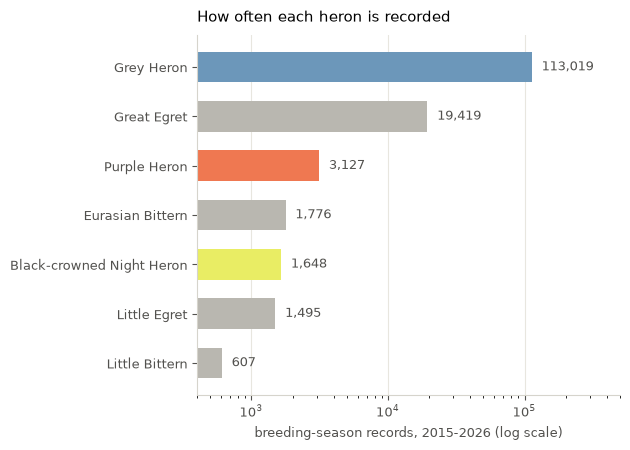

In [16]:
SPECIES_COLOUR = {
    "Grey Heron": "#6c97ba",
    "Black-crowned Night Heron": "#e9ed64",
    "Purple Heron": "#ef7851",
}

def colour_of(name):
    return SPECIES_COLOUR.get(name, "#b9b7b0")


# ---- the chart ---------------------------------------------------------------
# sort the bars
ranked = sorted(species, key=lambda s: len(s["values"]))
names = [s["name"] for s in ranked]
counts = [len(s["values"]) for s in ranked]

fig, ax = plt.subplots(figsize=(6.4, 4.6))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

ax.barh(names, counts, height=0.62, color=[colour_of(n) for n in names])
ax.set_xscale("log")          
ax.set_xlim(400, 500000)

# add value labels
for i, count in enumerate(counts):
    ax.text(count * 1.18, i, f"{count:,}", va="center", fontsize=9, color="#52514e")

ax.set_title("How often each heron is recorded", fontsize=11, color="black",
             loc="left", pad=10)
ax.set_xlabel("breeding-season records, 2015-2026 (log scale)",
              fontsize=9, color="#52514e")
ax.xaxis.grid(True, color="#e8e6df", lw=0.8)
ax.set_axisbelow(True)
ax.tick_params(colors="#52514e", labelsize=9.5)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color("#d6d4cc")

fig.tight_layout()
fig.savefig("assets/species_records.png", dpi=160, facecolor="white")
plt.show()

A second chart compares the same herons by how built-up their surroundings are,
using the shares calculated above.

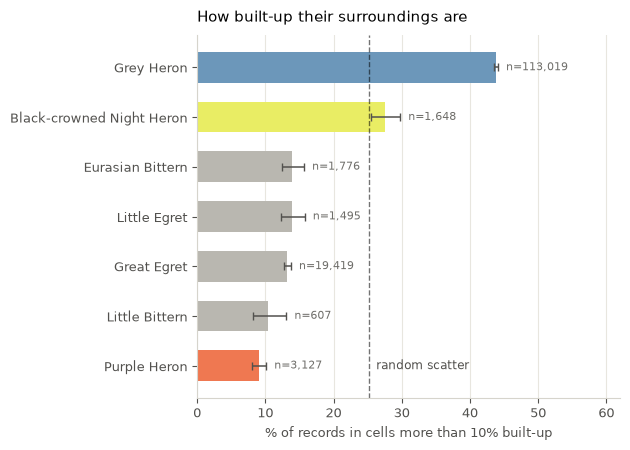

In [17]:
# sort the bars
ranked = sorted(species, key=lambda s: s["used"])
names = [s["name"] for s in ranked]
shares = [s["used"] * 100 for s in ranked]

# error bars are distances from the bar end, not absolute positions
errors = [[(s["used"] - s["lo"]) * 100 for s in ranked],
          [(s["hi"] - s["used"]) * 100 for s in ranked]]

fig, ax = plt.subplots(figsize=(6.4, 4.6))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

ax.barh(names, shares, height=0.62, color=[colour_of(n) for n in names],
        xerr=errors, error_kw=dict(ecolor="#52514e", lw=1.1, capsize=3))

ax.axvline(available * 100, color="black", lw=1, ls="--", alpha=0.55)
ax.text(available * 100 + 1, 0, "random scatter",
        fontsize=8.5, color="#52514e", va="center")

# the count belongs beside the bar: a share from 607 records is not the same
# claim as a share from 113,000, and the reader should see which is which
for i, s in enumerate(ranked):
    ax.text(s["hi"] * 100 + 1.2, i, f"n={len(s['values']):,}",
            va="center", fontsize=8, color="#6f6e6a")

ax.set_xlim(0, 62)
ax.set_title("How built-up their surroundings are", fontsize=11, color="black",
             loc="left", pad=10)
ax.set_xlabel(f"% of records in cells more than {THRESHOLD}% built-up",
              fontsize=9, color="#52514e")
ax.xaxis.grid(True, color="#e8e6df", lw=0.8)
ax.set_axisbelow(True)
ax.tick_params(colors="#52514e", labelsize=9.5)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color("#d6d4cc")

fig.tight_layout()
fig.savefig("assets/species_urbanity.png", dpi=160, facecolor="white")
plt.show()

Grey herons are the herons you see in Germany, and the herons you see in German
cities. Of every 100 sightings, 44 fall in built-up places.

Night herons are scarce here. Germany sits at the northern edge of their range
and they are recorded about seventy times less often than grey herons. Even so,
28 of every 100 night heron sightings are in built-up places, second only to the
grey heron.


### Let's build the next chapters from our findings

#### Story Chapter 2: zoom to Germany

The global map zooms in to one country. Same GBIF tile service as the world map,
with `country=DE` added.

In [18]:
DE_TILES = GBIF_TILES + "&country=DE"

chapter_germany = write_chapter(
    title = "Down to Germany",
    text = "Germany records the heron family in large numbers. Nine species "
           "have been seen here, and one of them turns up almost everywhere "
           "there is water.",
    align = "lefty",
    wmslayer = DE_TILES,
    center = [7.16309, 51.20688],
    zoom = 5.5)


In [19]:
m_de = Map(basemap=BASEMAP, center=(51.05521, 7.38281), zoom=4.8)
m_de.add(TileLayer(url=DE_TILES, name="Ardeidae in Germany",
                   attribution='Occurrences: <a href="https://www.gbif.org">GBIF</a>',
                   max_zoom=16, opacity=0.85))
chapter_preview(chapter_germany, m_de)


![Chapter 2 preview: occurrences zoomed to Germany](../resources/heron_chapter2_germany.png "Chapter 2 preview: occurrences zoomed to Germany")

#### Story Chapter 3: the species, as points

Add observation points for the species, coloured by species, to see the
distribution in more detail.

One dot per 5 km grid cell, because repeated observations at the same place can be
different records of the same bird, and because a lighter file draws faster in the
browser.

In [20]:
POINTS_FILE = Path("assets/heron_points.geojson")
GRID = 0.05          # degrees, ~5 km at this latitude


sites_by_species = {}
for s in species:
    pts = np.load(RAW / "points" / f"{s['key']}_{TAG}.npy")
    sites = sorted({(round(round(float(a) / GRID) * GRID, 2),
                     round(round(float(b) / GRID) * GRID, 2)) for a, b in pts})
    sites_by_species[s["name"]] = sites
    print(f"{s['name']:<28}{len(pts):>8,} records -> {len(sites):>7,} sites")


features = []
with rasterio.open(raster_path) as src:
    for name, sites in sorted(sites_by_species.items(), key=lambda kv: -len(kv[1])):
        lons = [lon for lon, lat in sites]
        lats = [lat for lon, lat in sites]
        xs, ys = to3035.transform(lons, lats)
        built = [v[0] for v in src.sample(zip(xs, ys))]
        for (lon, lat), bu in zip(sites, built):
            features.append({
                "type": "Feature",
                "geometry": {"type": "Point", "coordinates": [lon, lat]},
                "properties": {"sp": name,
                               "bu": int(round(float(bu))) if bu != src.nodata else 0},
            })

POINTS_FILE.parent.mkdir(exist_ok=True)
POINTS_FILE.write_text(
    json.dumps({"type": "FeatureCollection", "features": features},
               separators=(",", ":")), encoding="utf-8")
print(f"\n{POINTS_FILE}  {POINTS_FILE.stat().st_size/1e6:.1f} MB  "
      f"{len(features):,} points")

Grey Heron                   113,256 records ->  10,454 sites
Great Egret                   19,464 records ->   2,996 sites
Purple Heron                   3,130 records ->     260 sites
Eurasian Bittern               1,777 records ->     443 sites
Black-crowned Night Heron      1,651 records ->     321 sites
Little Egret                   1,503 records ->     331 sites
Little Bittern                   607 records ->     101 sites

assets\heron_points.geojson  1.7 MB  14,906 points


In [22]:
# radius setting
DOT_SIZE = ["interpolate", ["linear"], ["zoom"], 5, 2.2, 10, 5]

species_layer = geojson_layer(
    "assets/heron_points.geojson",
    colour = SPECIES_COLOUR,        
    colour_default = "#b9b7b0",
    size = DOT_SIZE,
    stroke = 0.6,
    source_id = "heron_dots")  # shared with the next chapter, so the browser loads this file once

chapter_species = write_chapter(
    title = "Where each one goes",
    text = "These are the seven species most often observed in Germany. <br> Grey herons are "
           "recorded almost everywhere there is water. Night herons keep to a "
           "few places along the southern rivers, and great egrets to the "
           "north and east.",
    align = "righty",
    image = "assets/species_records.png",
    geojson = species_layer,
    center = [10.45, 51.15],
    zoom = 5.8)

chapter_species

{'title': 'Where each one goes',
 'description': 'These are the seven species most often observed in Germany. <br> Grey herons are recorded almost everywhere there is water. Night herons keep to a few places along the southern rivers, and great egrets to the north and east.',
 'alignment': 'righty',
 'location': {'center': [10.45, 51.15], 'zoom': 5.8, 'bearing': 0, 'pitch': 0},
 'image': 'assets/species_records.png',
 'data': {'file': 'assets/heron_points.geojson',
  'circlePaint': {'circle-radius': ['interpolate',
    ['linear'],
    ['zoom'],
    5,
    2.2,
    10,
    5],
   'circle-color': ['match',
    ['get', 'sp'],
    'Grey Heron',
    '#6c97ba',
    'Black-crowned Night Heron',
    '#e9ed64',
    'Purple Heron',
    '#ef7851',
    '#b9b7b0'],
   'circle-opacity': 0.85,
   'circle-stroke-width': 0.6,
   'circle-stroke-color': '#00000033'},
  'sourceId': 'heron_dots'}}

To preview the map in ipyleaflet

In [23]:
# preview only: enough points to judge the framing, few enough for the browser.
preview_features = [
    f for i, f in enumerate(features)
    if f["properties"]["sp"] != "Grey Heron" or i % 8 == 0
]
print(f"{len(features):,} points in the file, {len(preview_features):,} drawn here")

m_species = Map(basemap=BASEMAP, center=(51.25, 13.95), zoom=5.8)
m_species.add(GeoJSON(
    data={"type": "FeatureCollection", "features": preview_features},
    point_style={"radius": 2, "fillOpacity": 0.75, "weight": 0},
    style_callback=lambda f: {"fillColor": colour_of(f["properties"]["sp"]),
                              "color": colour_of(f["properties"]["sp"])},
))

preview_map(m_species)


14,906 points in the file, 5,759 drawn here


![Observation points coloured by species](../resources/heron_map_species.png "Observation points coloured by species")

and have a look at the chapter layout

In [24]:
chapter_preview(chapter_species, m_species)


![Chapter 3 preview: the species card](../resources/heron_chapter3_species.png "Chapter 3 preview: the species card")

#### Story Chapter 4: show their urban association

The same points are recoloured, now by how built-up the place under each one is rather than by which bird was seen there. The dark clusters sit in the cities, and the paler points follow the rivers.

In [25]:
BUILTUP_RAMP = [(0, "#f6ded5"), (5, "#f2b49b"), (10, "#ef7851"),
                (25, "#c1462a"), (50, "#7d2413")]

builtup_colour = ["interpolate", ["linear"], ["get", "bu"]]
for value, hex_code in BUILTUP_RAMP:
    builtup_colour += [value, hex_code]

builtup_layer = geojson_layer(
    "assets/heron_points.geojson",
    colour = builtup_colour,
    size = DOT_SIZE,
    stroke = 0.6,
    layer_id = "heron_builtup",     
    source_id = "heron_dots")     # same layer used as last chapter   

chapter_urbanity = write_chapter(
    title = "Not every heron nests in town",
    text = "Now the urban association. The dark clusters are cities, where "
           "birdwatchers and herons pile up together. The pale dots scattered "
           "between them do something else: they follow the water. Zoom in and "
           "you can trace a river by the herons standing along it.",
    align = "righty",
    image = "assets/species_urbanity.png",
    geojson = builtup_layer,
    center = [9.84375, 51.15],
    zoom = 6)

chapter_urbanity

{'title': 'Not every heron nests in town',
 'description': 'Now the urban association. The dark clusters are cities, where birdwatchers and herons pile up together. The pale dots scattered between them do something else: they follow the water. Zoom in and you can trace a river by the herons standing along it.',
 'alignment': 'righty',
 'location': {'center': [9.84375, 51.15], 'zoom': 6, 'bearing': 0, 'pitch': 0},
 'image': 'assets/species_urbanity.png',
 'data': {'file': 'assets/heron_points.geojson',
  'circlePaint': {'circle-radius': ['interpolate',
    ['linear'],
    ['zoom'],
    5,
    2.2,
    10,
    5],
   'circle-color': ['interpolate',
    ['linear'],
    ['get', 'bu'],
    0,
    '#f6ded5',
    5,
    '#f2b49b',
    10,
    '#ef7851',
    25,
    '#c1462a',
    50,
    '#7d2413'],
   'circle-opacity': 0.85,
   'circle-stroke-width': 0.6,
   'circle-stroke-color': '#00000033'},
  'id': 'heron_builtup',
  'sourceId': 'heron_dots'}}

In [26]:
# every third dot: enough to see the pattern, few enough for the browser
builtup_features = features[::3]
print(f"{len(features):,} points in the file, {len(builtup_features):,} drawn here")

m_urbanity = Map(basemap=BASEMAP, center=(51.15, 10.45), zoom=7)
m_urbanity.add(GeoJSON(
    data={"type": "FeatureCollection", "features": builtup_features},
    point_style={"radius": 2, "fillOpacity": 0.85, "weight": 0},
    style_callback=lambda f: {
        "fillColor": [c for edge, c in BUILTUP_RAMP if f["properties"]["bu"] >= edge][-1]
    },
))
preview_map(m_urbanity)


14,906 points in the file, 4,969 drawn here


![Observation points coloured by built-up share](../resources/heron_map_builtup.png "Observation points coloured by built-up share")

I would like to move closer to have a better view on the points. So I updated the map position:

In [27]:
chapter_urbanity["location"]["center"] = [12.24, 49.11]
chapter_urbanity["location"]["zoom"] = 7
m_urbanity.center = (48.40, 12.26)


In [28]:
chapter_preview(chapter_urbanity, m_urbanity)


![Chapter 4 preview: the urban association card](../resources/heron_chapter4_urbanity.png "Chapter 4 preview: the urban association card")

### Habitat suitability of the urban trees

So how do our cities provide space for herons? I picked the grey heron as an example, the species that is the most widely distributed in Germany and the most closely tied to cities, and looked at individual urban trees to find out how suitable they are to nest on. The Habitat Suitability Index (HSI) follows the approach Lerman et al. (2014) developed for the i-Tree Wildlife module: literature-derived suitability curves per variable, combined as a geometric mean.

Four variables enter the index:

**Distance to the nearest water body**: grey herons are water birds. Breeding colonies are usually near their feeding areas, though exceptionally up to eight kilometres away, which makes this the dominant colony-site predictor in the literature (Tian et al. 2025).

**Tree height and crown diameter from the LiDAR tree model**: grey herons build bulky stick platforms high in tall, broad-crowned trees.

**Neighbourhood term counting nest-capable trees (height ≥ 15 m, crown ≥ 8 m) within 75 m**: herons are colonial, so an isolated giant is a poorer prospect than the same tree inside a stand.


| ID  | Variable                               | Breakpoints (value, SI)                                       | Confidence |
| :-- | :------------------------------------- | :------------------------------------------------------------ | :--------: |
| SI1 | Distance to nearest water body (m)     | (0, 1.00) (500, 1.00) (3000, 0.40) (8000, 0.05) (10000, 0.00) | high       |
| SI2 | Tree height (m)                        | (0, 0.00) (10, 0.00) (15, 0.50) (22, 1.00)                    | medium     |
| SI3 | Crown diameter (m)                     | (0, 0.00) (5, 0.00) (8, 0.50) (12, 1.00)                      | medium     |
| SI4 | Nest-capable trees within 75 m (count) | (0, 0.10) (2, 0.40) (5, 0.80) (10, 1.00)                      | medium     |


The four indices combine into one score as a geometric mean, which normalises the product of the four back to the range 0 to 1:

$$\mathrm{HSI} = \left(SI_1 \times SI_2 \times SI_3 \times SI_4\right)^{1/4}$$

Any variable scoring zero zeroes the tree, which is what leaves more than half the trees in the park at zero.


Distance to built-up area was, surprisingly, not used as a penalty, because the evidence points the other way: impervious surface appears neutral up to a threshold, and grey herons breed inside settlements where they go unpersecuted.

- The "lidar-based tree models" from:
Münzinger, Markus, 2025, "LiDAR-Based Tree Models for Munich, Germany (2012)", https://doi.org/10.71830/NDTUDB, ioerDATA, V1
- And "waterbody lands" from: WCS Service Indikator "Anteil Wasserfläche an Gebietsfläche" (F11RG), 2025, Rasterweite 100 m

Together they make a good data base.


#### Story Chapter 5: one park, tree by tree

And here are the results as geojson: a habitat suitability index for 1,371 individual
trees in a neighbourhood in Munich. 

The processing steps will later be shared.

In [29]:
HSI_FILE = Path("assets/hsi_trees.geojson")
hsi_features = json.loads(HSI_FILE.read_text(encoding="utf-8"))["features"]

print(f"{HSI_FILE}  {len(hsi_features):,} trees, {HSI_FILE.stat().st_size/1024:.0f} KB")


assets\hsi_trees.geojson  1,371 trees, 159 KB


In [30]:
HSI_RAMP = [(0, "#cfccc4"), (0.01, "#cde0c4"), (0.35, "#9cc389"),
            (0.7, "#5f9a56"), (1.0, "#2f6b34")]

hsi_colour = ["interpolate", ["linear"], ["get", "hsi"]]
for value, hex_code in HSI_RAMP:
    hsi_colour += [value, hex_code]

hsi_layer = geojson_layer(
    "assets/hsi_trees.geojson",
    colour = hsi_colour,
    # radius carries the score as well as the colour: an unsuitable tree
    # shrinks to a dot while a good one is unmissable. Zoom sets the base
    # size, the score scales it, so the two nest rather than compete.
    size = ["interpolate", ["linear"], ["zoom"],
            14, ["interpolate", ["linear"], ["get", "hsi"], 0, 1.5, 1, 4],
            17, ["interpolate", ["linear"], ["get", "hsi"], 0, 3, 1, 10]],
    stroke = 0.5,
    layer_id = "hsi_trees")

chapter_trees = write_chapter(
    title = "Which trees offer a home",
    text = "Grey herons can find room right next to us. Tall, wide urban "
           "trees give them somewhere to build, and the water nearby gives "
           "them somewhere to feed. Distance to built-up area, surprisingly, "
           "does not count against them. So let's zoom in on a neighbourhood "
           "near Nymphenburg. The larger and darker a point, the better that "
           "tree would hold a nest.",
    align = "lefty",
    geojson = hsi_layer,
    center = [11.48107, 48.15790],
    zoom = 17)

chapter_trees

{'title': 'Which trees offer a home',
 'description': "Grey herons can find room right next to us. Tall, wide urban trees give them somewhere to build, and the water nearby gives them somewhere to feed. Distance to built-up area, surprisingly, does not count against them. So let's zoom in on a neighbourhood near Nymphenburg. The larger and darker a point, the better that tree would hold a nest.",
 'alignment': 'lefty',
 'location': {'center': [11.48107, 48.1579],
  'zoom': 17,
  'bearing': 0,
  'pitch': 0},
 'data': {'file': 'assets/hsi_trees.geojson',
  'circlePaint': {'circle-radius': ['interpolate',
    ['linear'],
    ['zoom'],
    14,
    ['interpolate', ['linear'], ['get', 'hsi'], 0, 1.5, 1, 4],
    17,
    ['interpolate', ['linear'], ['get', 'hsi'], 0, 3, 1, 10]],
   'circle-color': ['interpolate',
    ['linear'],
    ['get', 'hsi'],
    0,
    '#cfccc4',
    0.01,
    '#cde0c4',
    0.35,
    '#9cc389',
    0.7,
    '#5f9a56',
    1.0,
    '#2f6b34'],
   'circle-opacity': 0.85,

In [31]:
m_trees = Map(basemap=BASEMAP, center=(48.15790, 11.48107), zoom=18)
m_trees.add(GeoJSON(
    data={"type": "FeatureCollection", "features": hsi_features},
    point_style={"fillOpacity": 0.9, "weight": 0},
    style_callback=lambda f: {
        "fillColor": [c for edge, c in HSI_RAMP if f["properties"]["hsi"] >= edge][-1],
        "radius": 2 + 6 * f["properties"]["hsi"],
    },
))
chapter_preview(chapter_trees, m_trees)


![Habitat suitability of single trees in one Munich park](../resources/heron_map_trees.png "Habitat suitability of single trees in one Munich park")

### The cover

The last thing we make is the first thing on screen, before any map: the cover and the hook. I found an engraving of herons by John G. Warnicke after Alexander Wilson, the father of American ornithology, in the collection of the National Gallery of Art. I derived the silhouettes from it and used them on the cover.

In [32]:
cover = {
    "title": "You know us already",
    "subtitle": "<i>Herons, and the space a city leaves them</i>",
    "image": "assets/silhouette.png",
}

# The hook is an optional full-screen paragraph between the cover and the first chapter
hook = {
    "description": (
        "Herons have been watched, painted, and photographed for centuries. "
        "They still stand where they always have: near water, and "
        "increasingly, inside cities. Scroll down to find them on the map."
    ),
    "image": "assets/heron_illustration.jpg",
    "alignment": "fully",
    "class": "hook",
    "location": {"center": [10.45, 51.15], "zoom": 5, "bearing": 0, "pitch": 30},
}

### The references

Don't forget to give credit to those who generously opened their data and images
for use. The references go in the footer.

In [33]:
footer = (
    "<b>Data</b><br>"
    "Occurrences from <a href='https://www.gbif.org'>GBIF</a>.<br>"
    "Built-up area from <a href='https://monitor.ioer.de'>IOER Monitor</a>, "
    "indicator S12RG (2025), 500 m raster.<br>"
    "Water bodies from IOER Monitor, indicator F11RG (2025), 100 m raster.<br>"
    "Tree models: Muenzinger, Markus (2025), "
    "<a href='https://doi.org/10.71830/NDTUDB'>LiDAR-Based Tree Models for "
    "Munich, Germany (2012)</a>, ioerDATA, V1."
    "<br><br>"
    "<b>Images</b><br>"
    "The illustration and the silhouettes are derived from Warnicke, "
    "John G. (after Alexander Wilson), "
    "<a href='https://www.nga.gov/artworks/73647-green-heron-night-heron-young-heron-and-great-white-heron'>"
    "<i>Green Heron, Night Heron, Young Heron, and Great White Heron</i></a>, "
    "1808-1814, National Gallery of Art, Washington, D.C."
)

## Export: write the story map

Now that the story is finished, `save_story` copies the page, its script and
its styles out of the template in `py/modules/storymap_template/`, brings the
assets along, and writes `_config.json` beside them. From that point the folder
is self-contained and knows nothing about Python.

Anything your story needs beyond the template - a cover image, a picture for a
chapter card, a GeoJSON layer - goes in the `assets` folder next to this
notebook, and every file in there is copied into the site. That is also how the
published page finds them again: the paths written into the chapters above,
`assets/silhouette.png` and the rest, are relative to the site root.

The config is validated against a JSON schema before it is written, so a mismatch
is reported here instead of failing silently in the browser.

The Storymap uses opensource layer tiles from [OpenFreeMap](https://openfreemap.org/), check there the available map styles you are able to use.

In [34]:
config = {
    "mapstyle": "positron",
    "location": {"center": [10.45, 51.15], "zoom": 3.5, "bearing": 0, "pitch": 0},
    "cover": cover,
    "intro": [hook],
    "chapters": [chapter1, chapter_germany, chapter_species,
                 chapter_urbanity, chapter_trees],
    "footer": footer,
}

site = save_story(config, site="../resources/storymap")
print(f"{site}/_config.json written, {len(config['chapters'])} chapters")

resources\storymap/_config.json written, 5 chapters


### See it running

The story map is a folder of static files, so once this notebook is published it
sits beside the page and can be embedded directly.

To check it locally, serve the folder first and open it in a browser, from the
repository root:

```
python -m http.server 8000 --directory resources
```

Then open <http://localhost:8000/storymap/index.html>. Serving `resources`
rather than the story map folder itself puts the page on the same path the
published site uses.

You can view the final story map <a href="/storymap/index.html" title="View the interactive story map">here</a>.